# E-commerce Review Datasets: Download and Compare

This notebook downloads several available e-commerce review datasets from Hugging Face,
saves a comparable sample for each dataset, and provides quick visual analysis for selection.

In [1]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.style.use('default')

d:\code\miniconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASETS = [
    {'name': 'amazon_polarity', 'split': 'train', 'text_col': 'content', 'label_col': 'label'},
    {'name': 'Ha1200/amazon-reviews-sentiment-analysis', 'split': 'train', 'text_col': 'reviewText', 'label_col': 'overall'},
    {'name': 'SetFit/amazon_reviews_multi_en', 'split': 'train', 'text_col': 'text', 'label_col': 'label'},
    {'name': 'juliensimon/amazon-shoe-reviews', 'split': 'train', 'text_col': 'text', 'label_col': 'labels'},
    {'name': 'saattrupdan/womens-clothing-ecommerce-reviews', 'split': 'train', 'text_col': 'review_text', 'label_col': 'rating'},
    {'name': 'm-ric/amazon_product_reviews_datafiniti', 'split': 'train', 'text_col': 'reviews.text', 'label_col': 'reviews.rating'},
]

def safe_name(name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9_-]+', '_', name)

In [3]:
base_dir = Path.cwd()
out_root = base_dir / 'ecommerce_candidates'
out_root.mkdir(parents=True, exist_ok=True)

summary_rows = []
for cfg in DATASETS:
    name = cfg['name']
    split = cfg['split']
    text_col = cfg['text_col']
    label_col = cfg['label_col']

    print(f'\nDownloading: {name} ({split})')
    ds = load_dataset(name, split=split)
    n = min(10000, len(ds))
    ds = ds.select(range(n))

    df = ds.to_pandas()
    keep_cols = [c for c in [text_col, label_col] if c in df.columns]
    slim = df[keep_cols].copy()
    slim = slim.rename(columns={text_col: 'text', label_col: 'label'})

    folder = out_root / safe_name(name)
    folder.mkdir(parents=True, exist_ok=True)
    out_csv = folder / 'sample_10k.csv'
    slim.to_csv(out_csv, index=False)

    summary_rows.append({
        'dataset': name,
        'rows_saved': len(slim),
        'text_non_null': int(slim['text'].notna().sum()) if 'text' in slim.columns else 0,
        'label_non_null': int(slim['label'].notna().sum()) if 'label' in slim.columns else 0,
        'avg_text_len': float(slim['text'].fillna('').astype(str).str.len().mean()) if 'text' in slim.columns else 0.0,
        'output_csv': str(out_csv)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(out_root / 'summary.csv', index=False)
summary_df


Downloading: amazon_polarity (train)

Downloading: Ha1200/amazon-reviews-sentiment-analysis (train)

Downloading: SetFit/amazon_reviews_multi_en (train)

Downloading: juliensimon/amazon-shoe-reviews (train)

Downloading: saattrupdan/womens-clothing-ecommerce-reviews (train)

Downloading: m-ric/amazon_product_reviews_datafiniti (train)


,dataset,rows_saved,text_non_null,label_non_null,avg_text_len,output_csv
0,amazon_polarity,10000,10000,10000,412.067500,d:\code\hk\584 nlp hk\project\dataset\ecommerc...
1,Ha1200/amazon-reviews-sentiment-analysis,4915,4914,4915,267.692981,d:\code\hk\584 nlp hk\project\dataset\ecommerc...
2,SetFit/amazon_reviews_multi_en,10000,10000,10000,171.858600,d:\code\hk\584 nlp hk\project\dataset\ecommerc...
3,juliensimon/amazon-shoe-reviews,10000,10000,10000,175.170100,d:\code\hk\584 nlp hk\project\dataset\ecommerc...
4,saattrupdan/womens-clothing-ecommerce-reviews,10000,10000,10000,308.684900,d:\code\hk\584 nlp hk\project\dataset\ecommerc...
5,m-ric/amazon_product_reviews_datafiniti,6000,6000,6000,137.641500,d:\code\hk\584 nlp hk\project\dataset\ecommerc...


## Quick Comparison Metrics

In [4]:
summary_view = summary_df[['dataset', 'rows_saved', 'avg_text_len', 'text_non_null', 'label_non_null']].copy()
summary_view = summary_view.sort_values('rows_saved', ascending=False)
summary_view

,dataset,rows_saved,avg_text_len,text_non_null,label_non_null
0,amazon_polarity,10000,412.067500,10000,10000
2,SetFit/amazon_reviews_multi_en,10000,171.858600,10000,10000
4,saattrupdan/womens-clothing-ecommerce-reviews,10000,308.684900,10000,10000
3,juliensimon/amazon-shoe-reviews,10000,175.170100,10000,10000
5,m-ric/amazon_product_reviews_datafiniti,6000,137.641500,6000,6000
1,Ha1200/amazon-reviews-sentiment-analysis,4915,267.692981,4914,4915


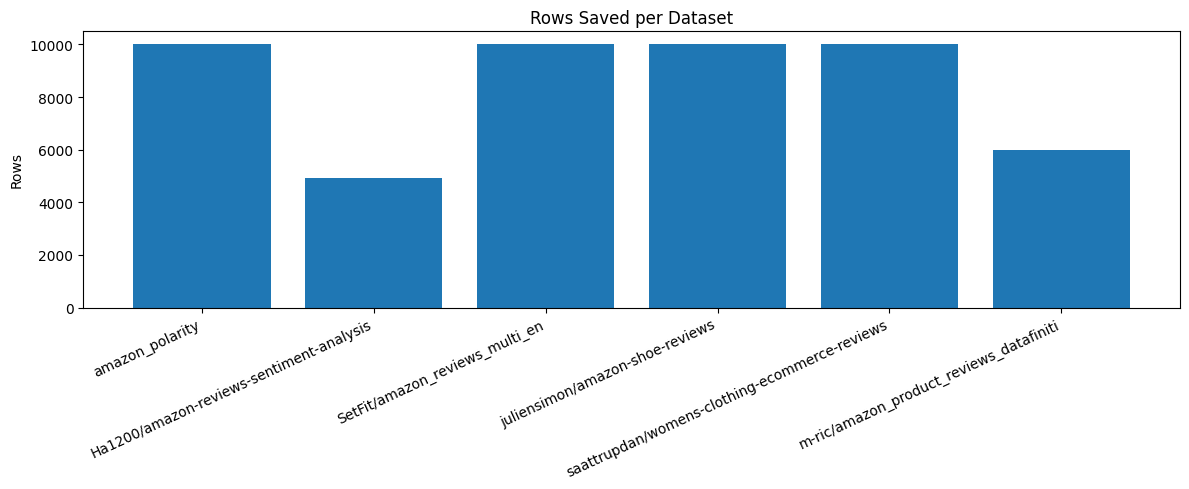

In [5]:
plt.figure(figsize=(12, 5))
plt.bar(summary_df['dataset'], summary_df['rows_saved'])
plt.title('Rows Saved per Dataset')
plt.ylabel('Rows')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

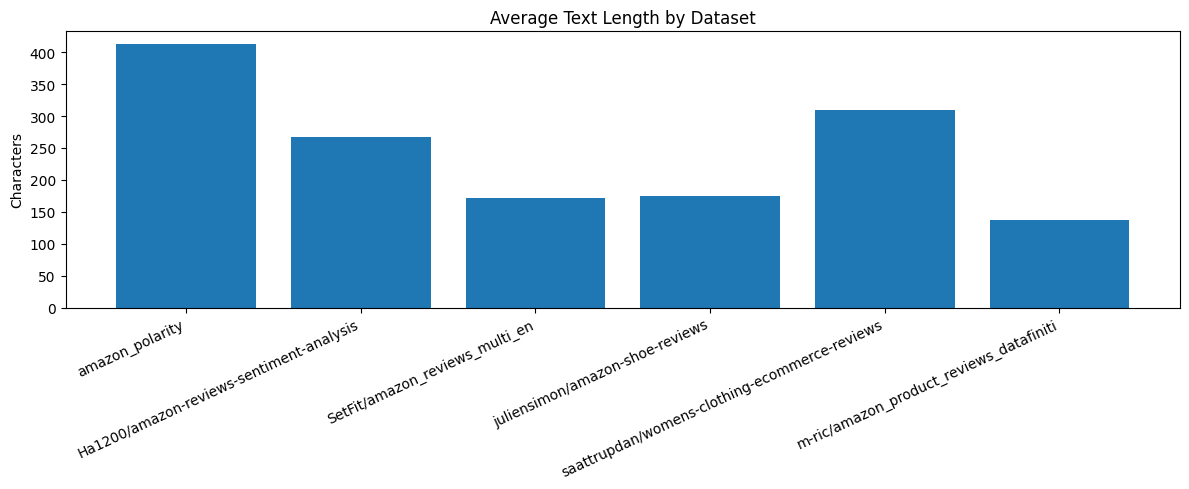

In [6]:
plt.figure(figsize=(12, 5))
plt.bar(summary_df['dataset'], summary_df['avg_text_len'])
plt.title('Average Text Length by Dataset')
plt.ylabel('Characters')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Print Sample Reviews

In [7]:
def print_samples(csv_path: Path, n: int = 3) -> None:
    print('=' * 100)
    print(csv_path)
    print('=' * 100)
    df = pd.read_csv(csv_path)
    sample = df.sample(n=min(n, len(df)), random_state=42)
    for i, row in enumerate(sample.itertuples(index=False), 1):
        text = str(getattr(row, 'text', ''))[:220].replace('\n', ' ')
        label = getattr(row, 'label', None)
        print(f'[{i}] label={label} | text={text}...')

for p in sorted(out_root.glob('*/sample_10k.csv')):
    print_samples(p, n=3)

d:\code\hk\584 nlp hk\project\dataset\ecommerce_candidates\amazon_polarity\sample_10k.csv
[1] label=0 | text=I'm so sorry to be such a spoilsport, but I found this is a terrible book and a worse series. Leaving aside all the wild inaccuracies - one of the main ones being Auel's portrayal of Neandertals as doltish brutes -the he...
[2] label=0 | text=This is the 4th Clavell book I've read, I was more than a little disappointed. I've read them in order so far, Shogun and Tai-pan for me were breathtaking, long books which I sped through. Gai-jin was more of a chore, wi...
[3] label=0 | text=I love books that make me laugh, and a friend told me about this book. I paid full price, and I feel somewhat had. Ms. Jensen has a gift for humor, but the plotting involved in this book is horrible. Good humor has to ha...
d:\code\hk\584 nlp hk\project\dataset\ecommerce_candidates\Ha1200_amazon-reviews-sentiment-analysis\sample_10k.csv
[1] label=5.0 | text=When I opened the micro disc and adapter I di

## Label Distribution (When Available)

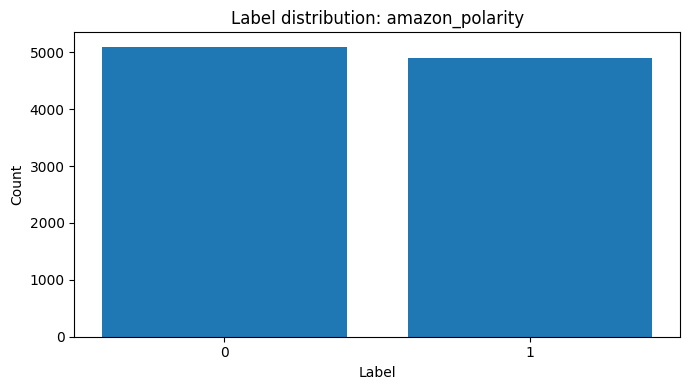

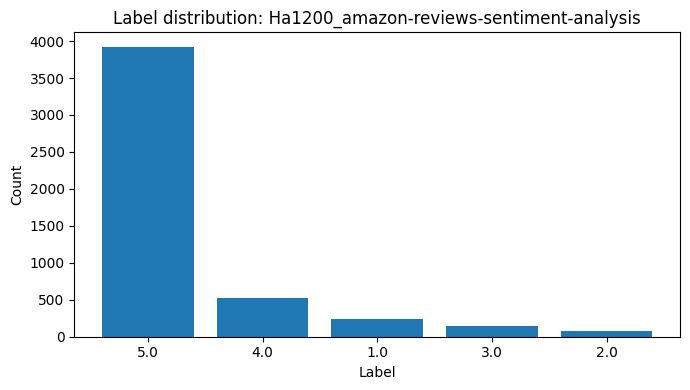

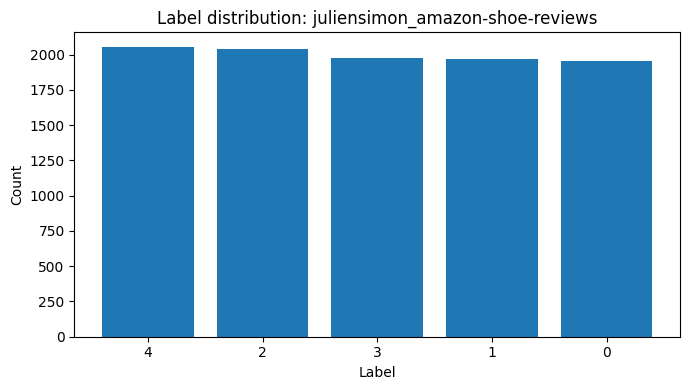

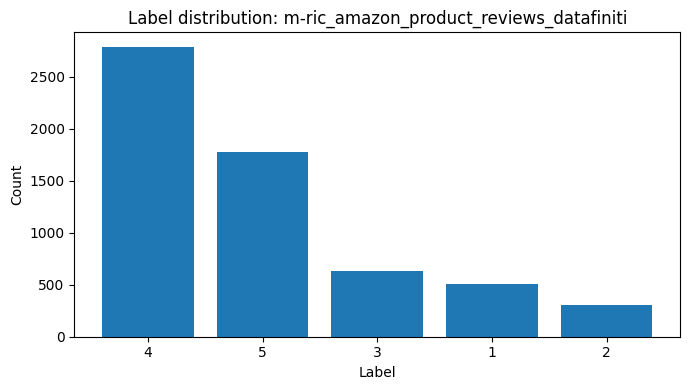

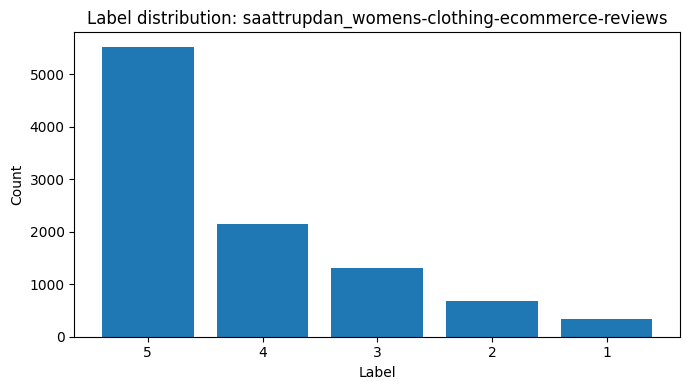

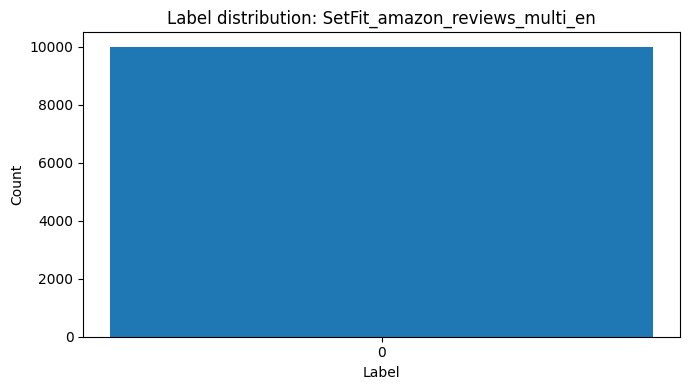

In [8]:
for p in sorted(out_root.glob('*/sample_10k.csv')):
    df = pd.read_csv(p)
    if 'label' not in df.columns:
        continue

    vc = df['label'].value_counts().head(10)
    plt.figure(figsize=(7, 4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f'Label distribution: {p.parent.name}')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Optional Next Filters for Selection

- Keep datasets with medium text length and enough rows (e.g. >= 5k)
- Prefer binary labels for quick baseline modeling
- For 5-class rating tasks, use datasets with balanced star distribution